--- REPEAT ORBIT ANALYSIS: 15 orbits in 1 days ---
Automatically Calculated Altitude: 569.20 km
Westward Drift per orbit: 23.99 degrees


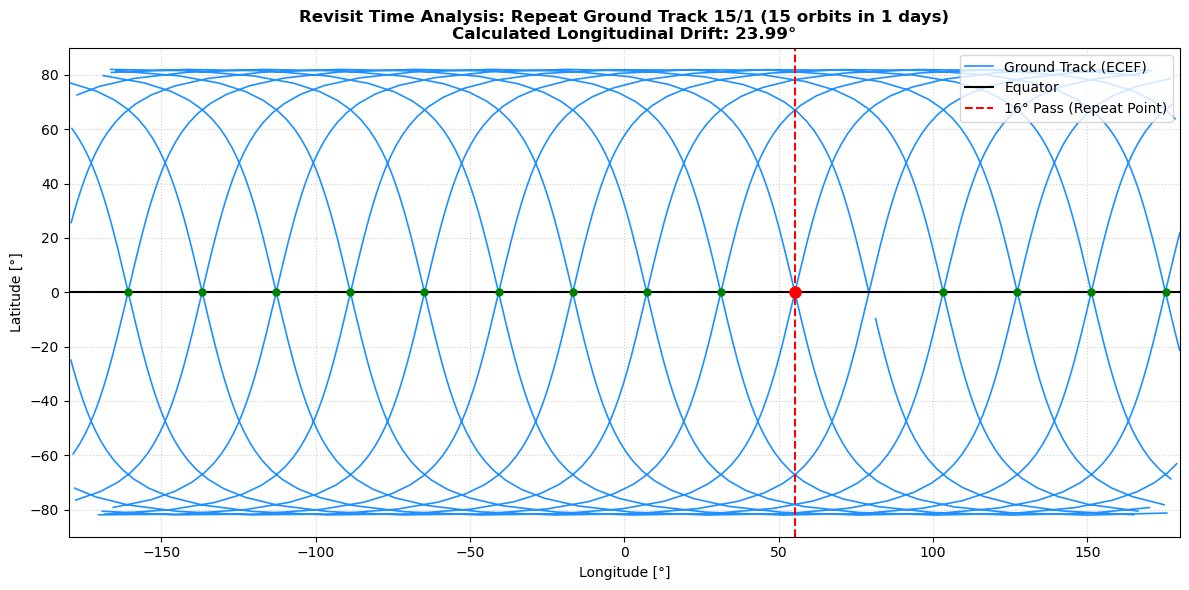

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import orekit
from orekit.pyhelpers import setup_orekit_curdir

# =========================================================================
# 1. OREKIT ENVIRONMENT INITIALIZATION
# =========================================================================
orekit.initVM()
setup_orekit_curdir('C:/Users/Simone/Downloads/orekit-data-main')

from org.orekit.orbits import KeplerianOrbit, PositionAngleType
from org.orekit.frames import FramesFactory
from org.orekit.time import TimeScalesFactory, AbsoluteDate
from org.orekit.utils import Constants, IERSConventions
from org.orekit.propagation.analytical import EcksteinHechlerPropagator
from org.orekit.models.earth import ReferenceEllipsoid

# =========================================================================
# 2. REPEAT-GROUND-TRACK RATIO DEFINITION
# =========================================================================
R = 15   # Number of orbits (Revolutions)
D = 1    # Number of Days

print(f"--- REPEAT ORBIT ANALYSIS: {R} orbits in {D} days ---")

mu = Constants.WGS84_EARTH_MU
R_earth = Constants.WGS84_EARTH_EQUATORIAL_RADIUS
J2 = Constants.WGS84_EARTH_C20 * -1.0
omega_earth = Constants.WGS84_EARTH_ANGULAR_VELOCITY

inc = math.radians(98.0) 
ecc = 0.001

# Analytical semi-major axis calculation compensated with J2 
T_target = (D * (2 * math.pi / omega_earth)) / R 
a = math.pow(mu * (T_target / (2 * math.pi))**2, 1/3)

for _ in range(5):
    p = a * (1 - ecc**2)
    n = math.sqrt(mu / a**3)
    d_omega = - (3/2) * J2 * (R_earth/p)**2 * n * math.cos(inc)
    d_M = (3/4) * J2 * (R_earth/p)**2 * n * math.sqrt(1 - ecc**2) * (3 * math.cos(inc)**2 - 1)
    
    n_pert = n + d_M
    omega_relativa = omega_earth - d_omega
    T_real = (D * 2 * math.pi) / (R * omega_relativa)
    a = math.pow(mu / (n_pert**2), 1/3)

alt_km = (a - R_earth) / 1000.0
print(f"Automatically Calculated Altitude: {alt_km:.2f} km")

# =========================================================================
# 3. PROPAGATION AND GROUND TRACK 
# =========================================================================
utc = TimeScalesFactory.getUTC()
epoch = AbsoluteDate(2026, 1, 1, 12, 0, 0.0, utc)
inertial_frame = FramesFactory.getEME2000()
earth_frame = FramesFactory.getITRF(IERSConventions.IERS_2010, True)

orbit = KeplerianOrbit(a, ecc, inc, 0.0, 0.0, 0.0, PositionAngleType.MEAN, inertial_frame, epoch, mu)
propagator = EcksteinHechlerPropagator(orbit, Constants.WGS84_EARTH_EQUATORIAL_RADIUS, 
                                     mu, Constants.WGS84_EARTH_C20, 0.0, 0.0, 0.0, 0.0)

# Simulating exactly D sidereal days
duration = D * 86164.09  
times = np.arange(0, duration + 60.0, 60.0)

lats, lons = [], []
earth = ReferenceEllipsoid.getWgs84(earth_frame)

for t in times:
    state = propagator.propagate(epoch.shiftedBy(float(t)))
    point = earth.transform(state.getPVCoordinates().getPosition(), inertial_frame, state.getDate())
    lats.append(math.degrees(point.getLatitude()))
    lons.append(math.degrees(point.getLongitude()))

lons_arr = np.array(lons)
lats_arr = np.array(lats)

# =========================================================================
# 4. DRIFT AND ASCENDING NODES CALCULATION (Equator Crossings)
# =========================================================================
crossings = np.where((lats_arr[:-1] < 0) & (lats_arr[1:] >= 0))[0]
cross_lons = []
for idx in crossings:
    lat1, lat2 = lats_arr[idx], lats_arr[idx+1]
    lon1, lon2 = lons_arr[idx], lons_arr[idx+1]
    if abs(lon2 - lon1) < 180:
        lon_cross = lon1 + (0 - lat1) * (lon2 - lon1) / (lat2 - lat1)
        cross_lons.append(lon_cross)

drift = 0
if len(cross_lons) > 1:
    drift = (cross_lons[0] - cross_lons[1]) % 360
    if drift > 180: drift = 360 - drift
print(f"Westward Drift per orbit: {drift:.2f} degrees")

# =========================================================================
# 5. GRAPHICAL VISUALIZATION 
# =========================================================================
# Inserting NaNs to break lines jumping from +180 to -180
diffs = np.abs(np.diff(lons_arr))
split_idx = np.where(diffs > 180)[0] + 1
lons_plot = np.insert(lons_arr, split_idx, np.nan)
lats_plot = np.insert(lats_arr, split_idx, np.nan)

fig, ax = plt.subplots(figsize=(12, 6))

# Base Track
ax.plot(lons_plot, lats_plot, color='dodgerblue', linewidth=1.2, label='Ground Track (ECEF)')

# Equator
ax.axhline(0, color='black', linewidth=1.5, label='Equator')

# Green Dots on Nodes
ax.plot(cross_lons, np.zeros_like(cross_lons), 'go', markersize=5, zorder=5)

# Red Dot and Vertical Line on the first node to show Overlap
if len(cross_lons) > 0:
    primo_nodo = cross_lons[0]
    ax.plot(primo_nodo, 0, 'ro', markersize=8, zorder=6)
    ax.axvline(primo_nodo, color='red', linestyle='--', linewidth=1.5, label=f'{R+1}° Pass (Repeat Point)')

ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xlabel("Longitude [°]")
ax.set_ylabel("Latitude [°]")
ax.set_title(f"Revisit Time Analysis: Repeat Ground Track {R}/{D} ({R} orbits in {D} days)\nCalculated Longitudinal Drift: {drift:.2f}°", fontweight='bold')
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()